In [34]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [35]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

arc_prize_2025_path = kagglehub.competition_download('arc-prize-2025')

print('Data source import complete.')


100%|██████████| 487k/487k [00:00<00:00, 64.6MB/s]

Extracting files...
Data source import complete.


In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [37]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt

def load_json(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

def get_random_task(data):
    task_id = random.choice(list(data.keys()))
    return task_id, data[task_id]

def plot_grid(grid, ax, title=""):
    ax.imshow(grid, cmap='tab10', vmin=0, vmax=9)
    ax.set_title(title)
    ax.axis('off')

def plot_full_task(task_id, task):
    print(f"Task ID: {task_id}")
    pairs = task["train"] + task["test"]
    num_pairs = len(pairs)

    fig, axs = plt.subplots(num_pairs, 2, figsize=(6, 3 * num_pairs))
    fig.suptitle("Train + Test Pairs", fontsize=16)

    for i, pair in enumerate(pairs):
        input_grid = np.array(pair["input"])
        output_grid = np.array(pair["output"]) if "output" in pair else np.zeros_like(input_grid)
        plot_grid(input_grid, axs[i][0], f"Input {i}")
        plot_grid(output_grid, axs[i][1], f"Output {i}")

    plt.tight_layout()
    plt.show()


In [38]:
from utils import load_task, visualize_task


In [39]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
dataset_path = "/content/drive/MyDrive/NLPGENAI/arc-agi-dataset-2025"
train_path = f"{dataset_path}/arc-agi_training_challenges.json"
eval_path = f"{dataset_path}/arc-agi_evaluation_challenges.json"


In [42]:
import json

with open("/content/drive/MyDrive/arc-prize-2025/arc-agi_training_challenges.json", 'r') as f:
    train_data = json.load(f)

print(f"Loaded {len(train_data)} training tasks")


Loaded 1000 training tasks


Showing Task ID: c97c0139


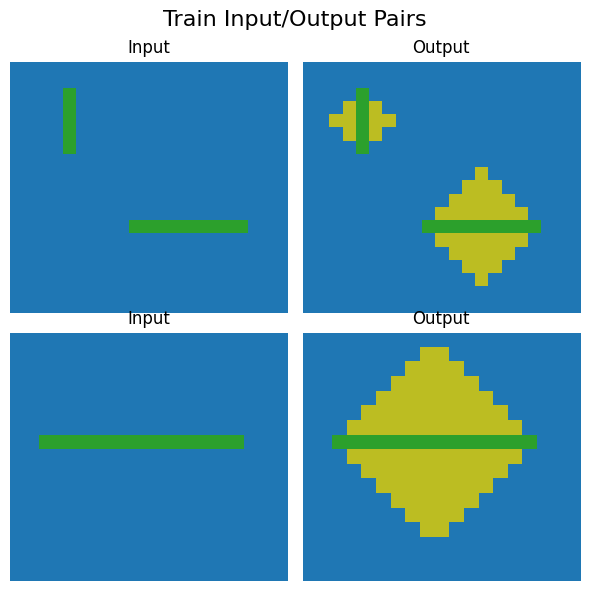

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Pick a random task ID
random_task_id = random.choice(list(train_data.keys()))
task = train_data[random_task_id]

def plot_grid(grid, ax, title=""):
    ax.imshow(grid, cmap="tab10", vmin=0, vmax=9)
    ax.set_title(title)
    ax.axis("off")

def plot_task(task_id, task):
    print(f"Showing Task ID: {task_id}")
    train_pairs = task["train"]

    fig, axs = plt.subplots(len(train_pairs), 2, figsize=(6, 3 * len(train_pairs)))
    fig.suptitle("Train Input/Output Pairs", fontsize=16)

    if len(train_pairs) == 1:
        axs = [axs]  # Make it iterable

    for i, pair in enumerate(train_pairs):
        plot_grid(np.array(pair["input"]), axs[i][0], "Input")
        plot_grid(np.array(pair["output"]), axs[i][1], "Output")

    plt.tight_layout()
    plt.show()

# Visualize it
plot_task(random_task_id, task)


Showing Task ID: c97c0139


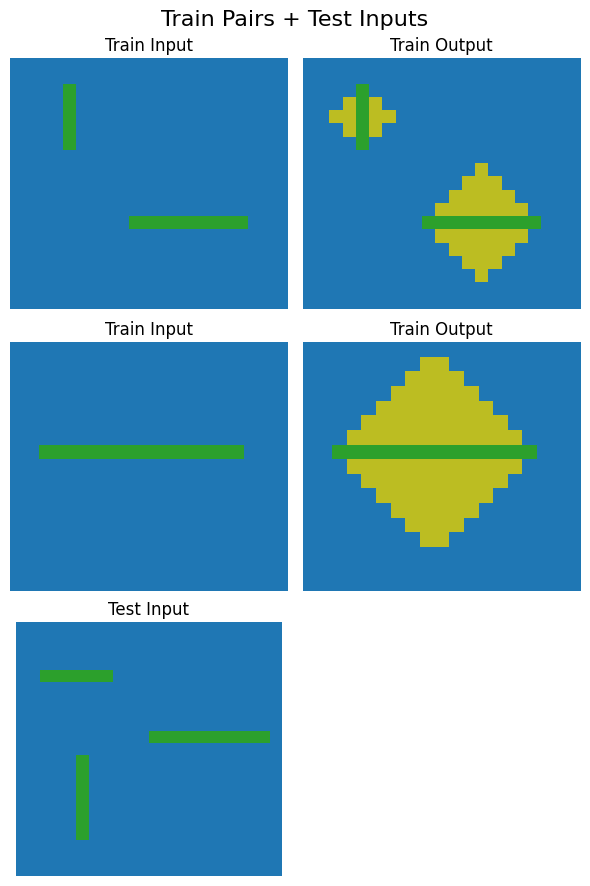

In [44]:
def plot_full_task(task_id, task):
    print(f"Showing Task ID: {task_id}")
    train_pairs = task["train"]
    test_inputs = task["test"]

    total_rows = len(train_pairs) + len(test_inputs)
    fig, axs = plt.subplots(total_rows, 2, figsize=(6, 3 * total_rows))
    fig.suptitle("Train Pairs + Test Inputs", fontsize=16)

    if total_rows == 1:
        axs = [axs]

    # Plot training input-output pairs
    for i, pair in enumerate(train_pairs):
        plot_grid(np.array(pair["input"]), axs[i][0], "Train Input")
        plot_grid(np.array(pair["output"]), axs[i][1], "Train Output")

    # Plot test inputs (no output available here)
    for i, pair in enumerate(test_inputs):
        plot_grid(np.array(pair["input"]), axs[len(train_pairs) + i][0], "Test Input")
        axs[len(train_pairs) + i][1].axis("off")

    plt.tight_layout()
    plt.show()

# Visualize full task
plot_full_task(random_task_id, task)


In [45]:
%%writefile visualize.py
import numpy as np
import matplotlib.pyplot as plt

def plot_grid(grid, ax, title=""):
    ax.imshow(grid, cmap="tab10", vmin=0, vmax=9)
    ax.set_title(title)
    ax.axis("off")

def plot_task(task_id, task):
    print(f"Task ID: {task_id}")
    train_pairs = task["train"]
    fig, axs = plt.subplots(len(train_pairs), 2, figsize=(6, 3 * len(train_pairs)))
    fig.suptitle("Train Input/Output Pairs", fontsize=16)
    if len(train_pairs) == 1:
        axs = [axs]
    for i, pair in enumerate(train_pairs):
        plot_grid(np.array(pair["input"]), axs[i][0], "Input")
        plot_grid(np.array(pair["output"]), axs[i][1], "Output")
    plt.tight_layout()
    plt.show()

def plot_full_task(task_id, task):
    print(f"Task ID: {task_id}")
    train_pairs = task["train"]
    test_inputs = task["test"]
    total_rows = len(train_pairs) + len(test_inputs)
    fig, axs = plt.subplots(total_rows, 2, figsize=(6, 3 * total_rows))
    fig.suptitle("Train + Test", fontsize=16)
    if total_rows == 1:
        axs = [axs]
    for i, pair in enumerate(train_pairs):
        plot_grid(np.array(pair["input"]), axs[i][0], "Train Input")
        plot_grid(np.array(pair["output"]), axs[i][1], "Train Output")
    for i, pair in enumerate(test_inputs):
        plot_grid(np.array(pair["input"]), axs[len(train_pairs) + i][0], "Test Input")
        axs[len(train_pairs) + i][1].axis("off")
    plt.tight_layout()
    plt.show()


Overwriting visualize.py


Showing Task ID: a3325580


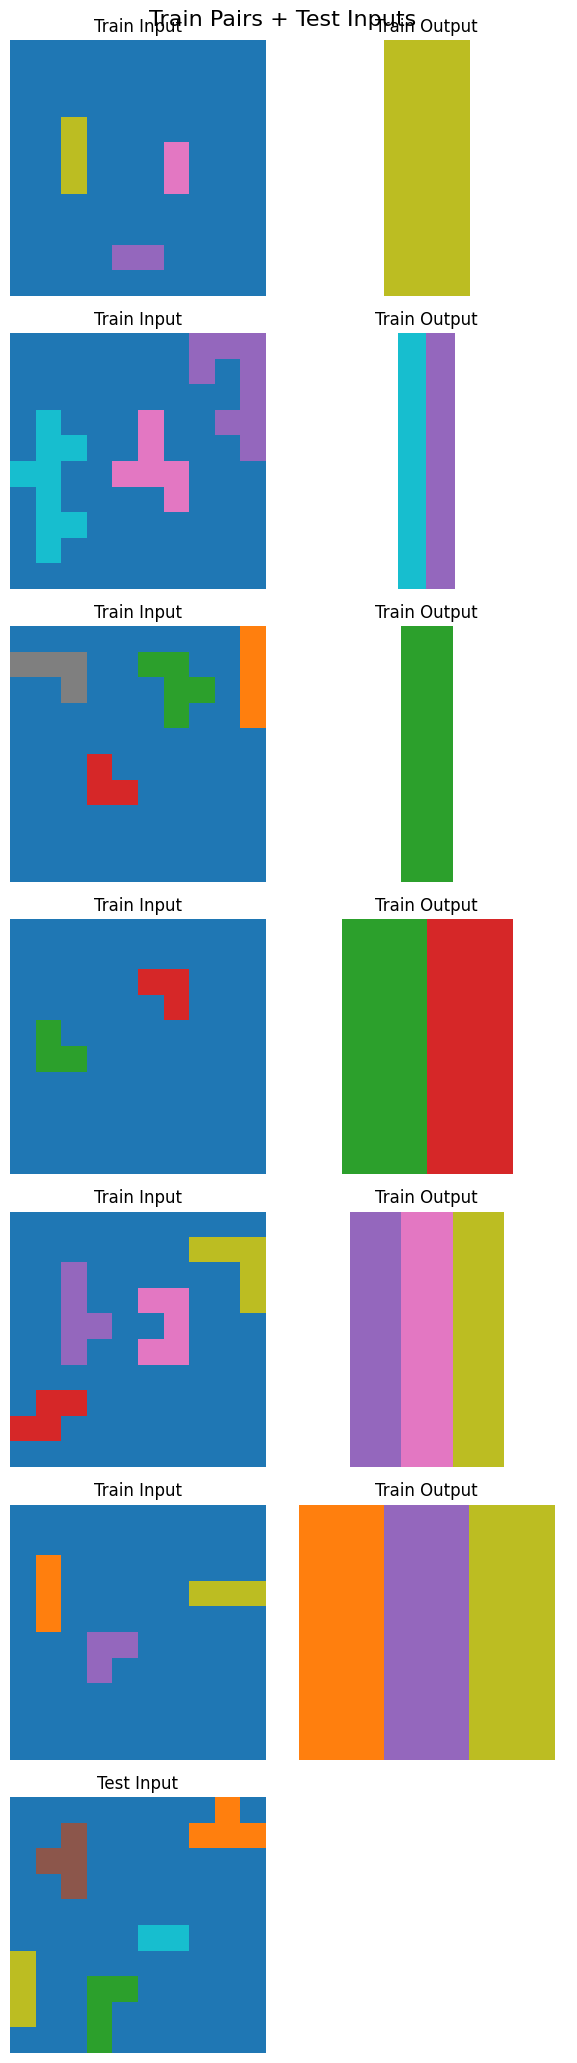

In [46]:
# Set paths
train_path = "/content/drive/MyDrive/arc-prize-2025/arc-agi_training_challenges.json"

# Load and visualize
train_data = load_json(train_path)
task_id, task = get_random_task(train_data)
plot_full_task(task_id, task)


In [47]:
!pip install numpy matplotlib


In [53]:
import json

def load_all_tasks(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data  # A dict with many task IDs as keys


In [54]:
import numpy as np

def parse_grids(task_dict):
    train_pairs = [(np.array(x['input']), np.array(x['output'])) for x in task_dict['train']]
    test_pairs = [(np.array(x['input']), np.array(x['output'])) for x in task_dict['test']]
    return train_pairs, test_pairs


In [55]:
import matplotlib.pyplot as plt

def plot_grid(grid, title=""):
    cmap = plt.get_cmap('tab20')
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=19)
    plt.title(title)
    plt.axis('off')
    plt.show()


In [57]:
def parse_grids(task_dict):
    train_pairs = [(np.array(x['input']), np.array(x['output'])) for x in task_dict['train']]

    test_pairs = []
    for x in task_dict['test']:
        input_grid = np.array(x['input'])
        output_grid = np.array(x['output']) if 'output' in x else None
        test_pairs.append((input_grid, output_grid))

    return train_pairs, test_pairs


In [58]:
import matplotlib.pyplot as plt

def plot_grid(grid, title=""):
    cmap = plt.get_cmap('tab20')  # 20 distinct colors
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=19)
    plt.title(title)
    plt.axis('off')
    plt.show()


In [59]:
def extract_task_features(task_dict):
    grid_shapes = [np.array(x['input']).shape for x in task_dict['train']]
    color_counts = [len(set(np.array(x['input']).flatten())) for x in task_dict['train']]

    avg_shape = np.mean([h * w for h, w in grid_shapes])
    avg_colors = np.mean(color_counts)

    return {
        "avg_shape": avg_shape,
        "avg_colors": avg_colors
    }


In [60]:
def route_task(features):
    if features["avg_colors"] <= 3 and features["avg_shape"] <= 49:
        return "Mistral"
    elif features["avg_shape"] > 100:
        return "Gemma"
    else:
        return "LLaMA"


In [61]:
features = extract_task_features(first_task_data)
model_choice = route_task(features)

print(f"Suggested model: {model_choice}")


Suggested model: LLaMA


In [62]:
def grid_to_string(grid):
    return '\n'.join([' '.join(map(str, row)) for row in grid])


In [64]:
def create_prompt(train_pairs, test_input_grid):
    example_input = grid_to_string(train_pairs[0][0])
    example_output = grid_to_string(train_pairs[0][1])

    test_input = grid_to_string(test_input_grid)

    prompt = f"""You are a reasoning AI helping to solve grid transformation tasks.
Each grid cell contains a number from 0 to 9 representing a color. Your goal is to transform the input grid to match the output pattern.

Here is one example:

Input:
{example_input}

Output:
{example_output}

Now solve this task:

Input:
{test_input}

Output:"""
    return prompt


In [65]:
import openai

def call_openai(prompt):
    response = openai.ChatCompletion.create(
        model="gpt-4",  # or gpt-3.5-turbo
        messages=[
            {"role": "system", "content": "You are a grid reasoning expert."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )
    return response['choices'][0]['message']['content']


In [66]:
def parse_output_to_grid(output_text):
    lines = output_text.strip().split('\n')
    grid = []
    for line in lines:
        row = [int(token) for token in line.strip().split() if token.isdigit()]
        if row:
            grid.append(row)
    return np.array(grid)


In [68]:
file_path = "/content/drive/MyDrive/arc-prize-2025/arc-agi_training_challenges.json"
all_tasks = load_all_tasks(file_path)
first_task_id = list(all_tasks.keys())[0]
first_task_data = all_tasks[first_task_id]


In [69]:
test_input = test[0][0]  # This now works!
prompt = create_prompt(train, test_input)

# Simulate model response (or call actual model)
response = """1 2 3\n4 5 6\n7 8 9"""  # Dummy example

# Parse model output
predicted_grid = parse_output_to_grid(response)

# Visualize
plot_grid(test_input, title="Test Input")
plot_grid(predicted_grid, title="Predicted Output")


NameError: name 'test' is not defined